
# <span style="color:rgb(213,80,0)">Segment and Analyze Brain MRI Scan Using AI</span>

This example shows how to preprocess, label, postprocess, and analyze a brain MRI image using MONAI Label.


In this example, you apply the wholeBrainSeg Large UNEST segmentation model \[1\] from the Medical Open Network for AI (MONAI) Label library. The MONAI Label \[2\]\[3\] platform provides fully automated and interactive deep learning models for segmenting radiology images, and you can connect to MONAI Label from within the [Medical Image Labeler](<docid:medical_ref#mw_3fec6056-dc05-42ca-8e06-301307d336b8>) app. To achieve satisfactory results from the wholeBrainSeg Large UNEST segmentation model, you must preprocess your data by registering it to an MNI305 atlas \[4\], which is a standardized brain atlas commonly used in neuroimaging analysis. In this example, you register the brain MRI data to the MNI305 atlas, segment it using the MONAI Label model, and transform the labels back to MRI space to calculate regional brain volumes.

## Import Brain MRI Data

Import the brain MRI scan as a `medicalVolume` object. The MRI volume is from the CANDI data set \[5\] \[6\], and the 2.3 MB scan is attached to this example as a supporting file.


In [1]:
medVolMRI = medicalVolume("brainSegData_anat.nii.gz")

medVolMRI = 
  medicalVolume with properties:
                 Voxels: [256x256x128 int16]
         VolumeGeometry: [1x1 medicalref3d]
           SpatialUnits: "mm"
            Orientation: "coronal"
           VoxelSpacing: [0.9375 0.9375 1.5000]
           NormalVector: [0 -1 0]
       NumCoronalSlices: 128
      NumSagittalSlices: 256
    NumTransverseSlices: 256
           PlaneMapping: ["sagittal"    "transverse"    "coronal"]
               Modality: "unknown"
          WindowCenters: 0
           WindowWidths: 0



Display the brain MRI scan as 3\-D slice planes.



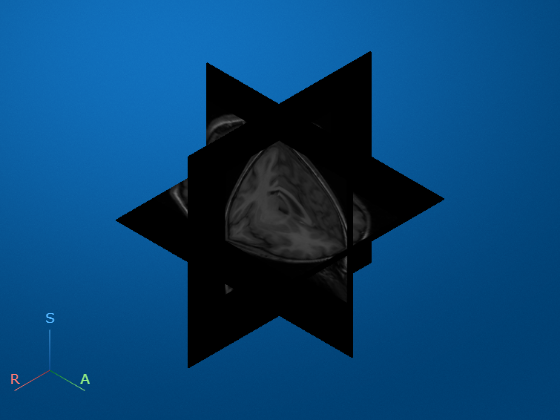

In [2]:
volshow(medVolMRI,RenderingStyle="SlicePlanes")

## Import Brain MNI Atlas

Import the MNI305 atlas image as a [`medicalVolume`](<docid:medical_ref#mw_c13c9472-21f7-4acf-b6da-87a54a1dee2b>) object. The atlas is attached to this example as a supporting file, and is approximately 2.8 MB.


In [3]:
atlas = medicalVolume("tpl-MNI305_T1w.nii.gz")

atlas = 
  medicalVolume with properties:
                 Voxels: [172x220x156 int16]
         VolumeGeometry: [1x1 medicalref3d]
           SpatialUnits: "mm"
            Orientation: "transverse"
           VoxelSpacing: [1 1 1]
           NormalVector: [0 0 1]
       NumCoronalSlices: 220
      NumSagittalSlices: 172
    NumTransverseSlices: 156
           PlaneMapping: ["sagittal"    "coronal"    "transverse"]
               Modality: "unknown"
          WindowCenters: 0
           WindowWidths: 0



Display the MNI atlas image as 3\-D slice planes.



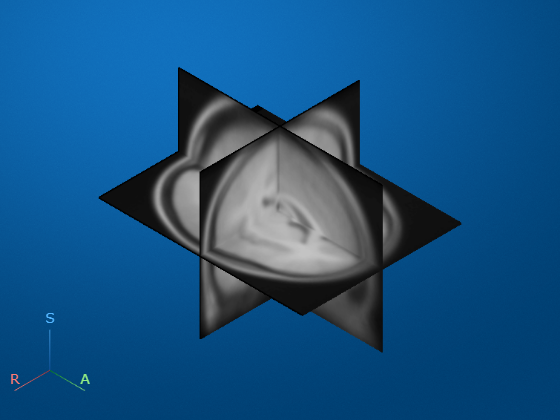

In [4]:
volshow(atlas,RenderingStyle="SlicePlanes")

## Register MRI to Atlas

Resample the brain MRI image so that it has the same voxel spacing as the brain atlas.


In [5]:
dataresampled = resample(medVolMRI,atlas.VolumeGeometry);


Register the resampled brain MRI scan to the atlas image using intensity\-based registration. To obtain the transformation matrix that describes the registration, use the `imregtform` function. Specify the transformation type as `"affine"` so the registration includes translation, rotation, and anisotropic scaling.


In [6]:
[optimizer,metric] = imregconfig("multimodal");
tform = imregtform(dataresampled.Voxels,atlas.Voxels, ...
    "affine",optimizer,metric);


The `tform` object describes the transformation from the MRI image to the atlas. Apply the transformation to the resampled MRI image using `imwarp`. Specify the output view so the size and location of the transformed image matches the atlas.


In [7]:
movingRegisteredVolume = imwarp(dataresampled.Voxels,tform, ...
    "OutputView",imref3d(size(atlas.Voxels)));


Create a `medicalVolume` object that contains the transformed MRI voxel data and the spatial referencing of the MNI atlas.


In [8]:
medVolRegistered = medicalVolume(movingRegisteredVolume,atlas.VolumeGeometry);

## Load Registered MRI into Medical Image Labeler

In this section you load the MRI scan, which has been transformed into MNI space, into the Medical Image Labeler app and perform segmentation using a MONAI Label deep learning network.

### Open Medical Image Labeler

Open the Medical Image Labeler app from the **Apps** tab on the MATLAB® Toolstrip, under **Image Processing and Computer Vision**. You can also load the app by using the `medicalImageLabeler` command.

### Create New Volume Labeling Session

To start a new 3\-D labeling session, on the app toolstrip, click **New Session** and select **New Volume Session (3\-D)**. In the Create a new session folder dialog box, specify a location in which to save the new session folder by entering a path, or select **Browse** and navigate to your desired location. In the New Session Folder dialog box, specify a name for the folder for this labeling session. Then, select **Create Session**.

### Import MRI Volume

To load the registered MRI volume into the app, on the app toolstrip, click **Import**, and, under **Data**, select **medicalVolume Object**. In the dialog box that opens, select `medVolRegistered` and click **OK**.

<p style="text-align:left">
   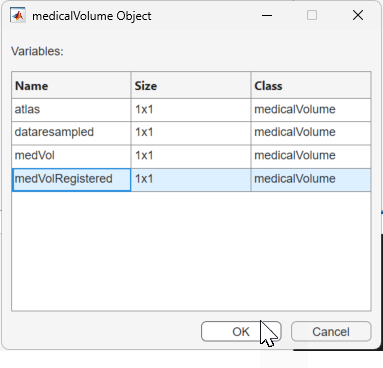
</p>


The registered MRI volume appears in the app.

<p style="text-align:left">
   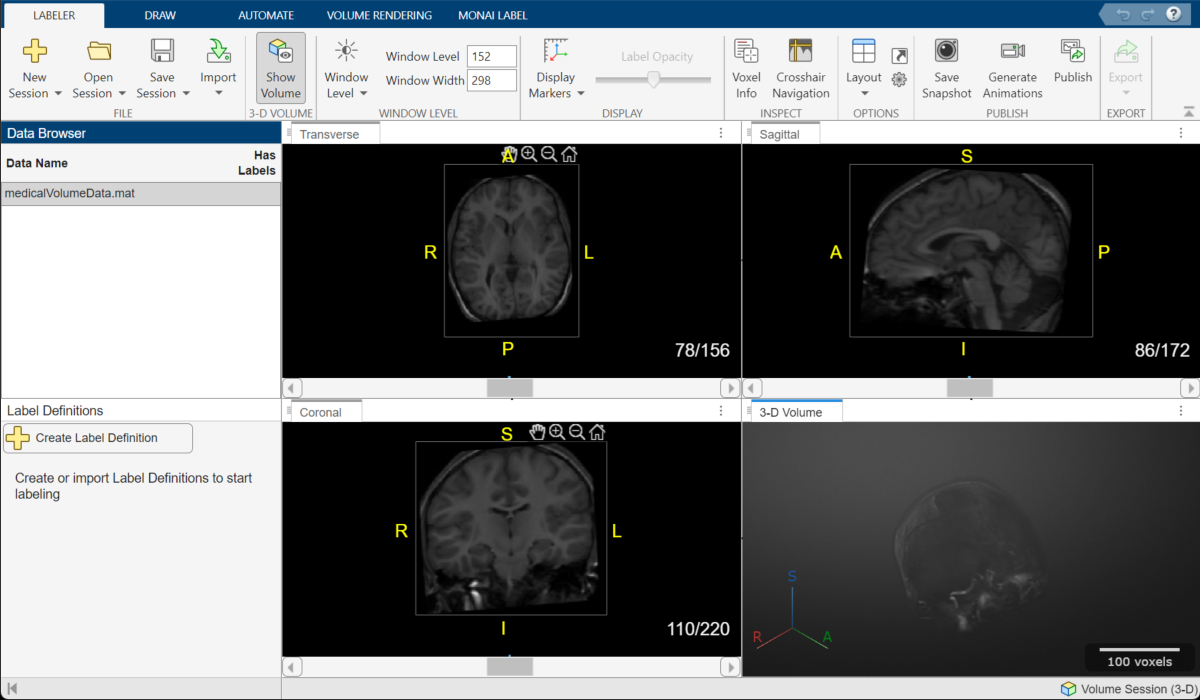
</p>

## Segment MRI Volume
### Start MONAI Label

On the **MONAI Label** tab of the app toolstrip, select **Start MONAI Label > On the local machine**. If this is the first time you are connecting to a local server, Medical Image Labeler prompts you to install the Medical Imaging Toolbox Interface for MONAI Label Library support package, which includes the MONAI Label software. Follow the link in the dialog box to open the Add\-On Explorer. To learn more about connecting to MONAI Label, see [Get Started with MONAI Label in Medical Image Labeler](<docid:medical_ug#mw_8efa80e6-5e46-4811-95c4-b6bb28fac774>). For more information about installing add\-ons, see [Get and Manage Add\-Ons](<docid:matlab_env#buytlwx>). When you install the support package, MATLAB downloads the MONAI Label models, which requires an internet connection.


Once the installation is complete, try starting MONAI Label again. You do not need to restart the app.

### Choose Brain MRI Segmentation Model

To select the brain segmentation model, on the **MONAI Label** tab of the app toolstrip, from the **Deep Learning Models** gallery, select the **wholeBrainSeg Large UNEST segmentation** model.


<p style="text-align:left">
   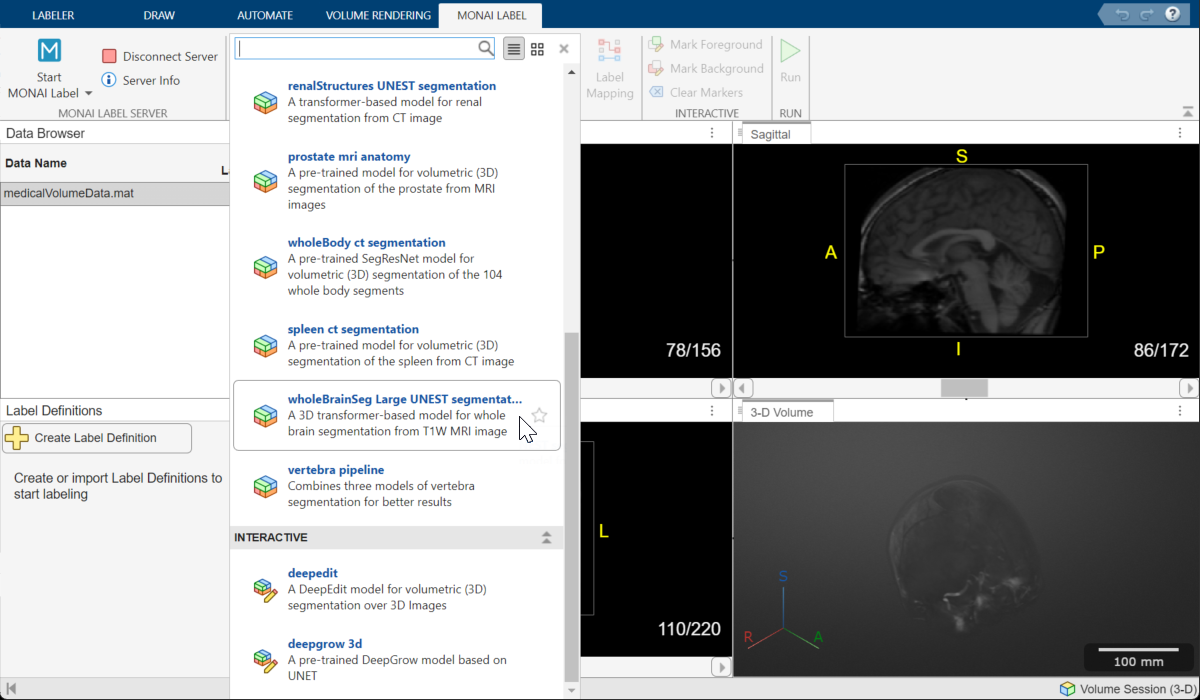
</p>

### Perform Label Mapping

Use the Label Mapping dialog box to map labels predicted by the MONAI Label model to labels in the **Label Definitions** pane of the Medical Image Labeler app. In the dialog box, click **Select All** to pick all the labels. In the **Label Definition in App** column, the default `<Create New>` option enables the app to create new label definitions. Click **OK** to save your choices. The new labels appear in the **Label Definitions** pane of the app window.

<p style="text-align:left">
   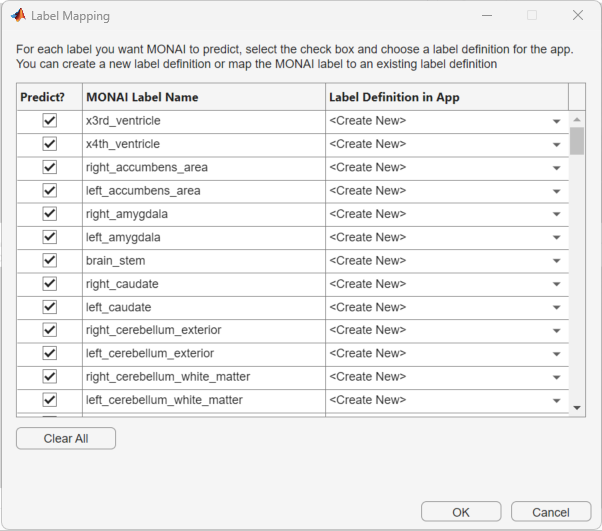
</p>

### Run the Model

In the app toolstrip, select **Run**. When the model finishes, the slice planes update to show the predicted labels. Overall, the results look satisfactory. This example uses the initial labels, and removes noise near the image boundary during postprocessing. For your data and application, you can choose to manually clean labels inside the brain using any of the manual or semi\-automated drawing tools in the app.

<p style="text-align:left">
   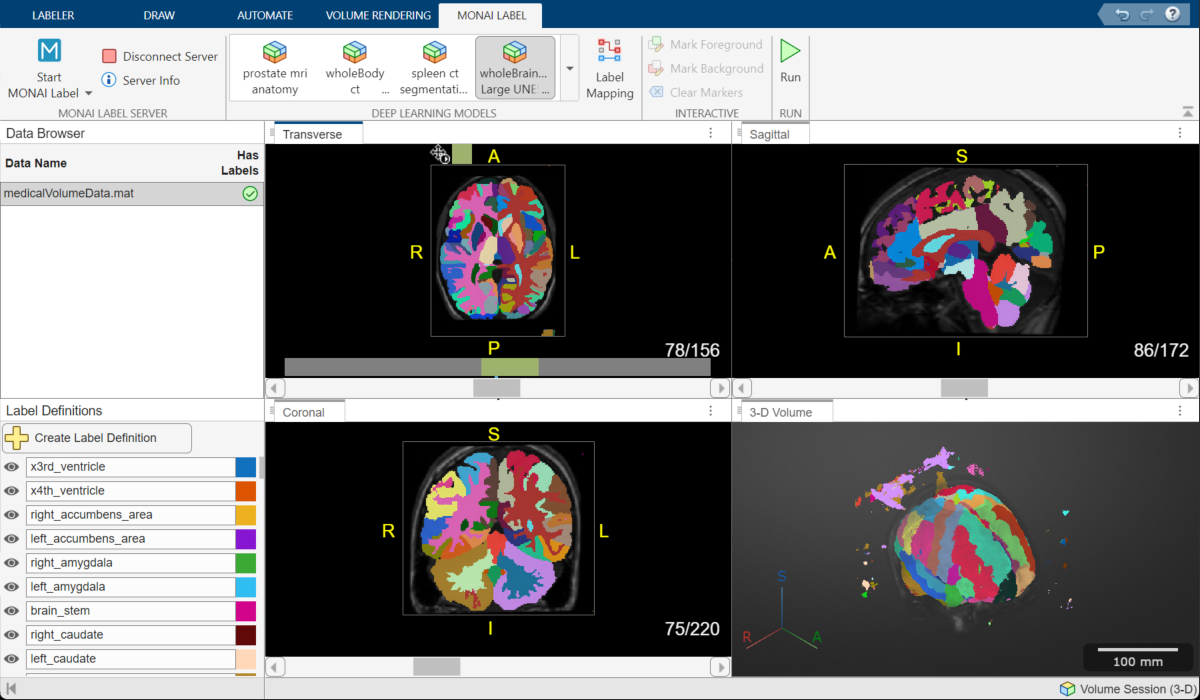
</p>

### Export Ground Truth

From the **Labeler** tab of the app toolstrip, select **Export**, and, under **Ground Truth**, select **To File**. Specify the location to save the ground truth using the Export Ground Truth dialog box, and click **Save**. The app exports a `groundTruthMedical` object in the MAT file format.

## Postprocess Results
### Import Ground Truth

This example creates a new `groundTruthMedical` object that simulates you exporting results from the app to your local machine. Create the ground truth object using the `createGroundTruthMed` helper function, which is defined at the end of this example.


In [9]:
gTruthMed = createGroundTruthMed;


Alternatively, if you complete the previous sections and export your own `groundTruthMedical` object to the file location `gTruthFileName`, load the object using this code.

<pre>
load(gTruthFileName)
</pre>

Import the label data from the ground truth as a `medicalVolume` object.


In [10]:
labelVol = medicalVolume(gTruthMed.LabelData);


Display the registered brain MRI image as fully transparent, with the MONAI\-predicted labels as an opaque overlay. As expected, the MRI data and labels are aligned.



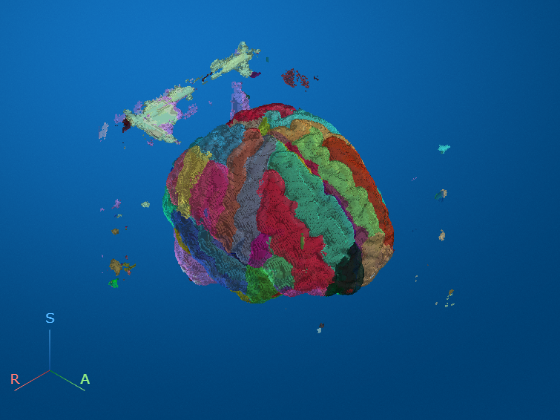

In [11]:
volshow(medVolRegistered, ...
    alphamap=0, ...
    OverlayData=labelVol.Voxels, ...
    OverlayAlpha=0.5);


Remove the noisy voxels at the edge of the slices by using the `filterNoisyVoxels` helper function defined at the end of the example. The helper function loops through each label definition, and keeps only the largest connected component for that label.


In [12]:
numLabels = size(gTruthMed.LabelDefinitions,1);
labelVolFilt = filterNoisyVoxels(labelVol,numLabels);


Display the postprocessed labels. As desired, the noisy voxels have been removed.



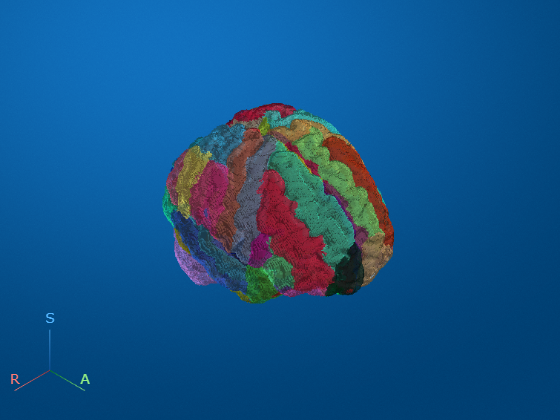

In [13]:
volshow(medVolRegistered, ...
    alphamap=0, ...
    OverlayData=labelVolFilt.Voxels, ...
    OverlayAlpha=0.5)


You can more closely inspect the internal postprocessed labels using the slice planes rendering style.



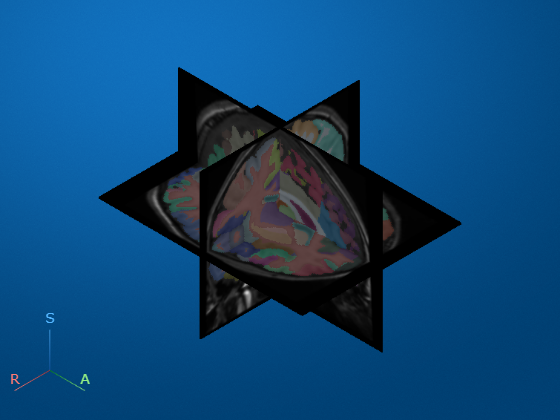

In [14]:
volshow(medVolRegistered, ...
    RenderingStyle="SlicePlanes", ...
    OverlayData=labelVolFilt.Voxels)

## Transform Labels Back to MRI Space from MNI Space

The `labelVolFilt` volume is in the MNI space. To transform the labels back to the original brain MRI space, apply the inverse of `tform` to the labels. Specify the interpolation method as `"nearest"`, which is the appropriate value for categorical label data to prevent rounding artifacts at the edges of label regions.


In [15]:
tformInv = invert(tform);
labelVolMRI = imwarp(labelVolFilt.Voxels,tformInv,"nearest", ...
    OutputView=imref3d(size(dataresampled.Voxels)));


Create a `medicalVolume` object containing the labels in MRI space with the same spatial referencing as the unregistered, resampled Brain MRI image.


In [16]:
medVolLabelsMRI = medicalVolume(labelVolMRI,dataresampled.VolumeGeometry);


Resample the labels back to the original voxel spacing of the MRI scan.


In [17]:
medVolLabelsMRI = resample(medVolLabelsMRI,medVolMRI.VolumeGeometry,Method="nearest");


Display the original MRI scan with the transformed, resampled labels as an overlay.



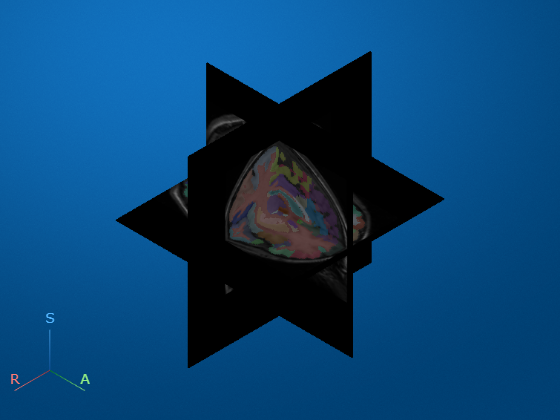

In [18]:
volshow(medVolMRI, ...
    RenderingStyle="SlicePlanes", ...
    OverlayData=medVolLabelsMRI.Voxels)

## Analyze Segmented MRI Volume

Calculate the volume of different brain structures and the overall brain volume. First, you must get the label names, which are stored in the `LabelDefinitions` field of the `groundTruthMedical` object.


In [19]:
labelDefs = gTruthMed.LabelDefinitions


Extract the label names to a new table for volume results.


In [20]:
results = labelDefs(:,"Name");


Calculate the number of voxels in each label using the `regionprops3` function.


In [21]:
S = regionprops3(medVolLabelsMRI.Voxels,"Volume");
numVoxels = S.Volume;


To calculate the volume of each voxel, in cubic centimeters, convert the voxel spacing from mm to cm, and then multiply the spacing in all three directions. Then, calculate the volume of each label in cubic centimeters.


In [22]:
dv = prod(0.1*medVolMRI.VoxelSpacing);
volume = numVoxels.*dv;


Append the volume values to the `results` table.


In [23]:
results.("Volume (voxels)") = numVoxels;
results.("Volume (ccm)")= volume


Calculate the total brain volume, in cubic centimeters. The total brain volume is 1446 cubic cm, which is in the normal range for human brain volume \[7\].


In [24]:
totalBrainVol = sum(volume)

totalBrainVol = 1.4462e+03


## Supporting Function

The `filterNoisyVoxels` helper function removes small clusters of noisy label voxels using these steps:

1.  While looping through each of the labels, create a binary mask for the current label.
2. Find the connected components in the mask by using the `bwconncomp` function with a connectivity value of `6`.
3. Calculate the number of voxels in each connected component using the `numel` function.
4. Determine the indices of voxels in the connected component with the most voxels.
5. Set all label values for voxels outside the largest connected component to `0`, which is the background. This step removes the small noisy voxels.

In [25]:
function labelVolFilt = filterNoisyVoxels(labelVol,numLabels)

labelVolFilt = labelVol;

for i = 1:numLabels

    maskLabel_i = labelVol.Voxels==i;
    CC = bwconncomp(maskLabel_i,6);
    numPixels = cellfun(@numel,CC.PixelIdxList);
    [~,idx] = max(numPixels);
    maskLabel_i(CC.PixelIdxList{idx}) = 0;

    labelVolFilt.Voxels(maskLabel_i==1) = 0;

end
end


The `createGroundTruthMed` helper function creates a `groundTruthMedical` object that points to the label results on your local machine. The files used to create the ground truth object are all attached to this example as supporting files. You can also create them yourself by following the processes in the Import Brain MRI Data, Import Brain MNI Atlas, Register MRI to Atlas, Load Registered MRI into Medical Image Labeler, and Segment MRI Volume sections of this example, and exporting a `groundTruthMedical` object from the app.


In [26]:
function gTruthMed = createGroundTruthMed

dataFile = {"registeredVol.nii.gz"};
dataSource = medical.labeler.loading.VolumeSource(dataFile);
labelData = "medicalVolumeData.nii";
load("labelDefinitions.mat");

gTruthMed = groundTruthMedical(dataSource,labelDefinitions,labelData);

end

## References
<a id="M_4220"></a>

\[1\] Yu, Xin, Qi Yang, Yinchi Zhou, Leon Y. Cai, Riqiang Gao, Ho Hin Lee, Thomas Li, et al. “UNesT: Local Spatial Representation Learning with Hierarchical Transformer for Efficient Medical Segmentation.” *Medical Image Analysis* 90 (December 1, 2023): 102939. [https://doi.org/10.1016/j.media.2023.102939](https://doi.org/10.1016/j.media.2023.102939).

<a id="M_33da"></a>

\[2\] Diaz\-Pinto, Andres, Sachidanand Alle, Vishwesh Nath, Yucheng Tang, Alvin Ihsani, Muhammad Asad, Fernando Pérez\-García, et al. “MONAI Label: A Framework for AI\-Assisted Interactive Labeling of 3D Medical Images,” 2022. [https://doi.org/10.48550/ARXIV.2203.12362](https://doi.org/10.48550/ARXIV.2203.12362).

<a id="M_063f"></a>

\[3\] Diaz\-Pinto, Andres, Pritesh Mehta, Sachidanand Alle, Muhammad Asad, Richard Brown, Vishwesh Nath, Alvin Ihsani, et al. “DeepEdit: Deep Editable Learning for Interactive Segmentation of 3D Medical Images.” In *Data Augmentation, Labelling, and Imperfections*, edited by Hien V. Nguyen, Sharon X. Huang, and Yuan Xue, 11–21. Lecture Notes in Computer Science. Cham: Springer Nature Switzerland, 2022. [https://doi.org/10.1007/978\-3\-031\-17027\-0\_2](https://doi.org/10.1007/978-3-031-17027-0_2).

<a id="M_55b2"></a>

\[4\] Evans, A.C., D.L. Collins, S.R. Mills, E.D. Brown, R.L. Kelly, and T.M. Peters. “3D Statistical Neuroanatomical Models from 305 MRI Volumes.” In *1993 IEEE Conference Record Nuclear Science Symposium and Medical Imaging Conference*, 1813–17. San Francisco, CA, USA: IEEE, 1993. [https://doi.org/10.1109/NSSMIC.1993.373602](https://doi.org/10.1109/NSSMIC.1993.373602).

<a id="M_99bd"></a>

\[5\] “NITRC: CANDI Share: Schizophrenia Bulletin 2008: Tool/Resource Info.” Accessed October 17, 2022. [https://www.nitrc.org/projects/cs\_schizbull08/](https://www.nitrc.org/projects/cs_schizbull08/).

<a id="M_6a4a"></a>

\[6\] Frazier, J. A., S. M. Hodge, J. L. Breeze, A. J. Giuliano, J. E. Terry, C. M. Moore, D. N. Kennedy, et al. “Diagnostic and Sex Effects on Limbic Volumes in Early\-Onset Bipolar Disorder and Schizophrenia.” *Schizophrenia Bulletin* 34, no. 1 (October 27, 2007): 37–46. [https://doi.org/10.1093/schbul/sbm120](https://doi.org/10.1093/schbul/sbm120).

<a id="M_5270"></a>

\[7\]   Kijonka, Marek, Damian Borys, Krzysztof Psiuk\-Maksymowicz, Kamil Gorczewski, Piotr Wojcieszek, Bartosz Kossowski, Artur Marchewka, Andrzej Swierniak, Maria Sokol, and Barbara Bobek\-Billewicz. “Whole Brain and Cranial Size Adjustments in Volumetric Brain Analyses of Sex\- and Age\-Related Trends.” *Frontiers in Neuroscience* 14 (April 3, 2020). [https://doi.org/10.3389/fnins.2020.00278](https://doi.org/10.3389/fnins.2020.00278).


*Copyright 2024 The MathWorks, Inc.*

